In [19]:
%pip install pandas numpy matplotlib seaborn scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el dataset
df = pd.read_csv('OnlineNewsPopularity.csv')

# 2. Limpiar espacios en blanco en los nombres de las columnas
df.columns = [col.strip() for col in df.columns]

# 3. Eliminar columnas no predictivas
df_clean = df.drop(['url', 'timedelta'], axis=1)

print(f"Dataset cargado con éxito.")
print(f"Filas: {df_clean.shape[0]} | Columnas: {df_clean.shape[1]}")


[notice] A new release of pip is available: 23.2.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Dataset cargado con éxito.
Filas: 39644 | Columnas: 59


In [20]:
# 4. Revisar información general
print(df_clean.info())

# 5. Revisar valores faltantes
print("\nValores faltantes por columna:")
print(df_clean.isnull().sum().sort_values(ascending=False))

# 6. Revisar duplicados
print("\nFilas duplicadas:", df_clean.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 39644 entries, 0 to 39643
Data columns (total 59 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   n_tokens_title                 39644 non-null  float64
 1   n_tokens_content               39644 non-null  float64
 2   n_unique_tokens                39644 non-null  float64
 3   n_non_stop_words               39644 non-null  float64
 4   n_non_stop_unique_tokens       39644 non-null  float64
 5   num_hrefs                      39644 non-null  float64
 6   num_self_hrefs                 39644 non-null  float64
 7   num_imgs                       39644 non-null  float64
 8   num_videos                     39644 non-null  float64
 9   average_token_length           39644 non-null  float64
 10  num_keywords                   39644 non-null  float64
 11  data_channel_is_lifestyle      39644 non-null  float64
 12  data_channel_is_entertainment  39644 non-null  float64
 1

In [21]:
# 7. Estadísticas descriptivas
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
n_tokens_title,39644.0,10.398749,2.114037,2.00000,9.000000,10.000000,12.000000,23.000000
n_tokens_content,39644.0,546.514731,471.107508,0.00000,246.000000,409.000000,716.000000,8474.000000
n_unique_tokens,39644.0,0.548216,3.520708,0.00000,0.470870,0.539226,0.608696,701.000000
n_non_stop_words,39644.0,0.996469,5.231231,0.00000,1.000000,1.000000,1.000000,1042.000000
n_non_stop_unique_tokens,39644.0,0.689175,3.264816,0.00000,0.625739,0.690476,0.754630,650.000000
num_hrefs,39644.0,10.883690,11.332017,0.00000,4.000000,8.000000,14.000000,304.000000
num_self_hrefs,39644.0,3.293638,3.855141,0.00000,1.000000,3.000000,4.000000,116.000000
num_imgs,39644.0,4.544143,8.309434,0.00000,1.000000,1.000000,4.000000,128.000000
num_videos,39644.0,1.249874,4.107855,0.00000,0.000000,0.000000,1.000000,91.000000
average_token_length,39644.0,4.548239,0.844406,0.00000,4.478404,4.664082,4.854839,8.041534


In [22]:
# Separar variable objetivo
X = df_clean.drop('shares', axis=1)
y = df_clean['shares']

print("X:", X.shape)
print("y:", y.shape)

X: (39644, 58)
y: (39644,)


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Datos escalados:", X_scaled.shape)

Datos escalados: (39644, 58)


In [24]:
import pandas as pd

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled_df.describe().T

,count,mean,std,min,25%,50%,75%,max
n_tokens_title,39644.0,4.129479e-16,1.000013,-3.972899,-0.661657,-0.188622,0.757447,5.960828
n_tokens_content,39644.0,7.456003e-17,1.000013,-1.160078,-0.637898,-0.291900,0.359764,16.827550
n_unique_tokens,39644.0,-1.218770e-17,1.000013,-0.155714,-0.021969,-0.002554,0.017179,198.954458
n_non_stop_words,39644.0,-8.065388e-19,1.000013,-0.190487,0.000675,0.000675,0.000675,199.000326
n_non_stop_unique_tokens,39644.0,1.953616e-17,1.000013,-0.211094,-0.019430,0.000398,0.020049,198.883779
num_hrefs,39644.0,8.459696e-17,1.000013,-0.960449,-0.607463,-0.254476,0.275004,25.866534
num_self_hrefs,39644.0,-1.147077e-17,1.000013,-0.854360,-0.594963,-0.076169,0.183228,29.235709
num_imgs,39644.0,-2.007385e-17,1.000013,-0.546872,-0.426526,-0.426526,-0.065486,14.857501
num_videos,39644.0,1.613078e-18,1.000013,-0.304268,-0.304268,-0.304268,-0.060829,21.848691
average_token_length,39644.0,1.376493e-16,1.000013,-5.386389,-0.082705,0.137190,0.363100,4.137038


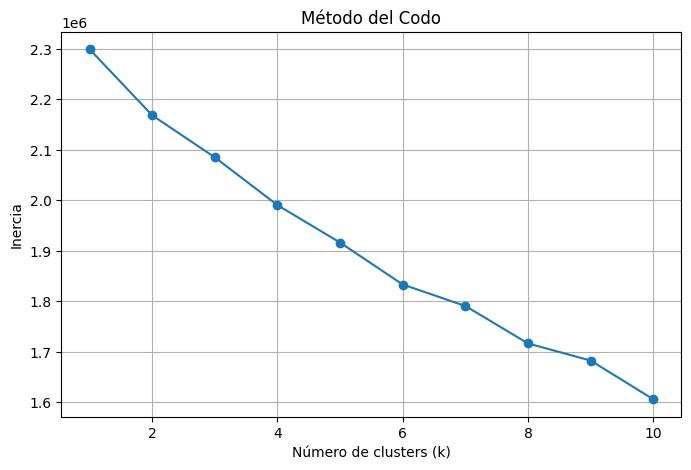

In [25]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Lista para guardar la inercia
inertia = []

# Probar valores de k del 1 al 10
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Graficar
plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.title("Método del Codo")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.grid()
plt.show()

In [26]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Agregar clusters al dataset
df_clean['cluster'] = clusters

# Ver resultados
df_clean['cluster'].value_counts()

cluster
0    21826
3    12234
2     4400
1     1184
Name: count, dtype: int64

In [27]:
cluster_analysis = df_clean.groupby('cluster').mean()

In [28]:
cluster_analysis[['shares',
                  'n_tokens_content',
                  'num_hrefs',
                  'num_imgs',
                  'num_videos',
                  'average_token_length']].round(2)

,shares,n_tokens_content,num_hrefs,num_imgs,num_videos,average_token_length
cluster,,,,,,
0,2706.97,585.01,10.00,2.92,0.46,4.71
1,4690.77,0.17,0.01,3.92,0.80,0.01
2,3324.51,480.73,9.40,3.45,1.16,4.66
3,4523.66,554.37,14.05,7.89,2.73,4.66


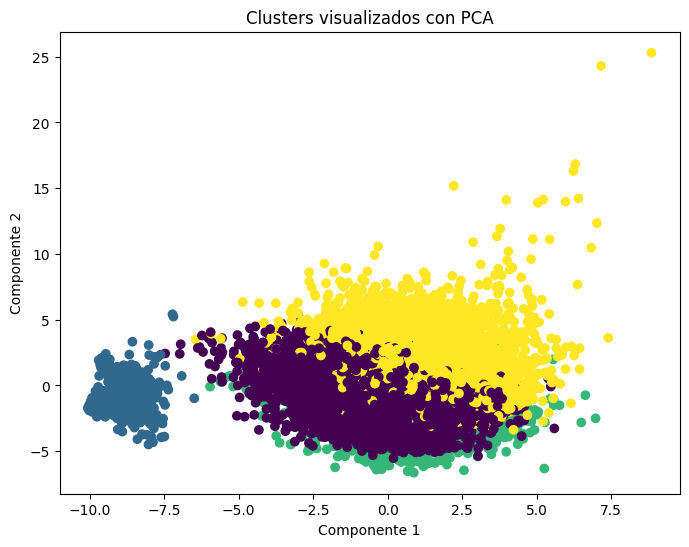

In [29]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reducir a 2 dimensiones
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Graficar
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df_clean['cluster'], cmap='viridis')
plt.title("Clusters visualizados con PCA")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()

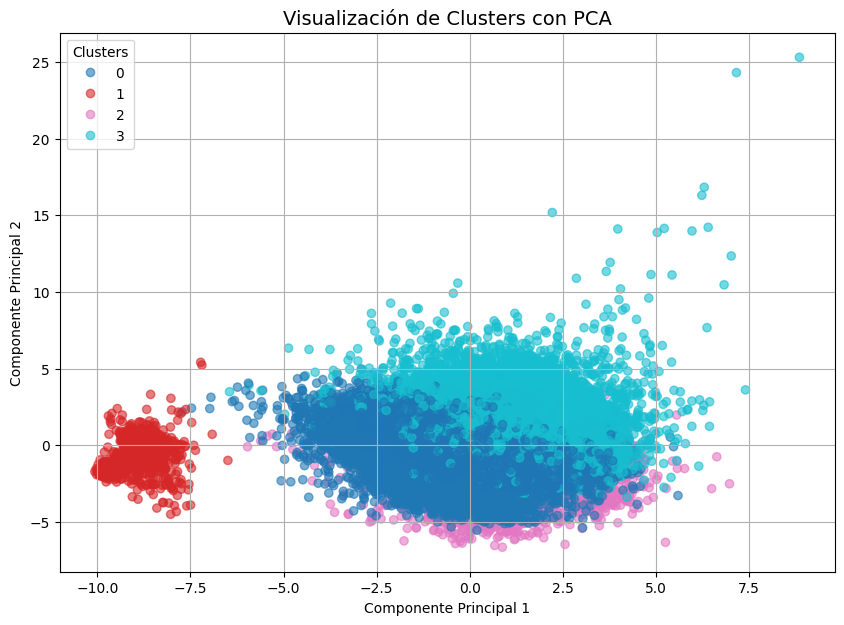

In [30]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Gráfica mejorada
plt.figure(figsize=(10,7))
scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df_clean['cluster'],
    cmap='tab10',   # colores más claros
    alpha=0.6       # transparencia
)

plt.title("Visualización de Clusters con PCA", fontsize=14)
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

# Leyenda automática
plt.legend(*scatter.legend_elements(), title="Clusters")

plt.grid(True)
plt.show()

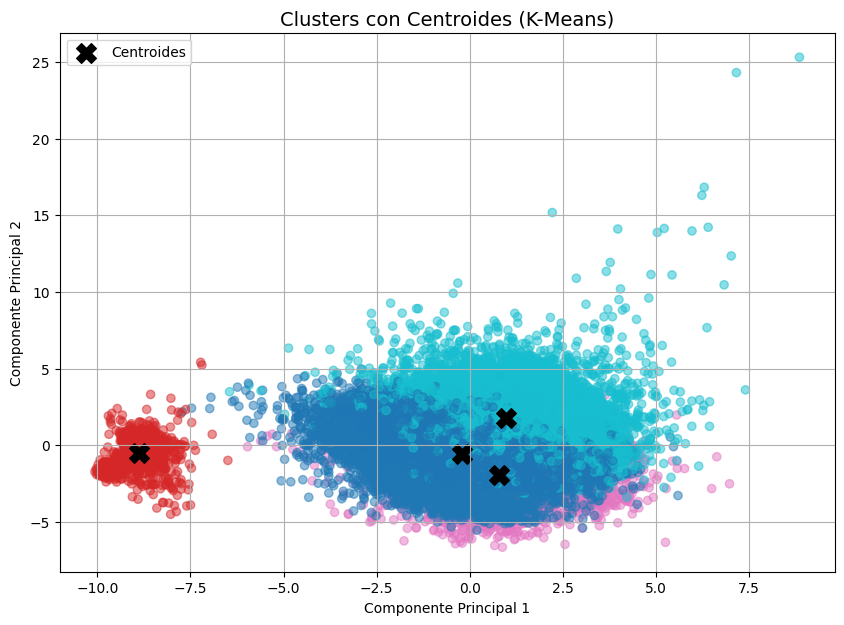

In [31]:
# Obtener centroides
centroids = kmeans.cluster_centers_

# Pasarlos a PCA
centroids_pca = pca.transform(centroids)

plt.figure(figsize=(10,7))

# Datos
scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df_clean['cluster'],
    cmap='tab10',
    alpha=0.5
)

# Centroides (los centros de los clusters)
plt.scatter(
    centroids_pca[:,0],
    centroids_pca[:,1],
    c='black',
    s=200,
    marker='X',
    label='Centroides'
)

plt.title("Clusters con Centroides (K-Means)", fontsize=14)
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.legend()
plt.grid(True)
plt.show()

# Tomar una muestra más pequeña
X_sample = X_scaled[:3000] 

from sklearn.cluster import AgglomerativeClustering

agglo = AgglomerativeClustering(n_clusters=4)
clusters_agglo = agglo.fit_predict(X_sample)

In [32]:
X_sample = X_scaled[:3000]

from sklearn.cluster import AgglomerativeClustering

agglo = AgglomerativeClustering(n_clusters=4)
clusters_agglo = agglo.fit_predict(X_sample)

In [33]:
import pandas as pd

pd.Series(clusters_agglo).value_counts()

0    1254
1     807
2     658
3     281
Name: count, dtype: int64

In [34]:
df_sample = df_clean.iloc[:3000].copy()
df_sample['cluster_agglo'] = clusters_agglo

In [35]:
df_sample.to_csv('dataset_muestra_clusterizado.csv', index=False)

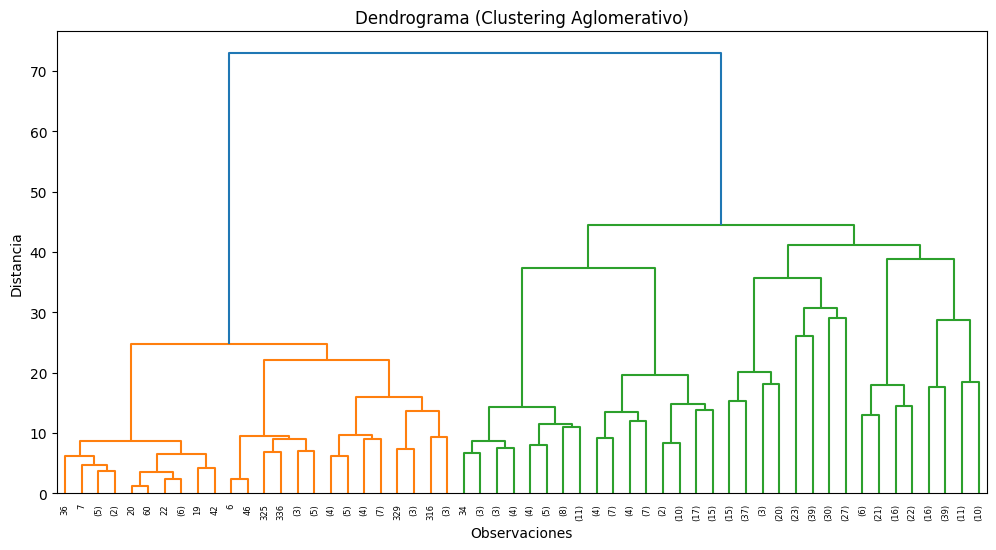

In [36]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Tomar submuestra para dendrograma
X_dendro = X_sample[:500]

# Crear estructura jerárquica
linked = linkage(X_dendro, method='ward')

# Graficar
plt.figure(figsize=(12,6))

dendrogram(
    linked,
    truncate_mode='level',
    p=5
)

plt.title("Dendrograma (Clustering Aglomerativo)")
plt.xlabel("Observaciones")
plt.ylabel("Distancia")

plt.show()

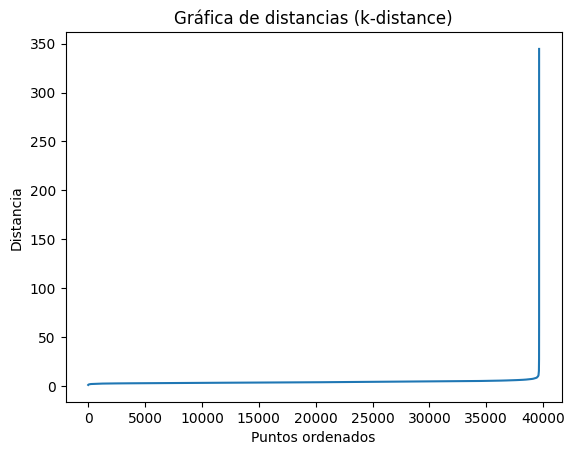

In [38]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:,4])  # 4 porque min_samples=5

plt.plot(distances)
plt.title("Gráfica de distancias (k-distance)")
plt.xlabel("Puntos ordenados")
plt.ylabel("Distancia")
plt.show()

In [39]:
import pandas as pd

df_distancias = pd.DataFrame({
    "distancia": distances
})

df_distancias.head(10)

,distancia
0,0.979726
1,1.032847
2,1.069030
3,1.069464
4,1.092963
5,1.108105
6,1.108105
7,1.136086
8,1.137595
9,1.152686


In [ ]:
from sklearn.cluster import DBSCAN

# muestra peque;a
sample = X_scaled[:15000]
sample_pca = X_pca[:15000]

#  DBSCAN
dbscan = DBSCAN(eps=6, min_samples=5)
clusters = dbscan.fit_predict(sample)

In [ ]:
import pandas as pd

print(pd.Series(clusters).value_counts())

 0    14258
-1      532
 2       93
 3       26
 5       21
 7       20
 1       15
 6       15
 4        9
 8        7
 9        4
Name: count, dtype: int64


In [55]:
ruido = clusters[clusters == -1]
print("Cantidad de ruido:", len(ruido))

Cantidad de ruido: 532


In [56]:
core_points = dbscan.core_sample_indices_
print("Cantidad de puntos núcleo:", len(core_points))

Cantidad de puntos núcleo: 13993


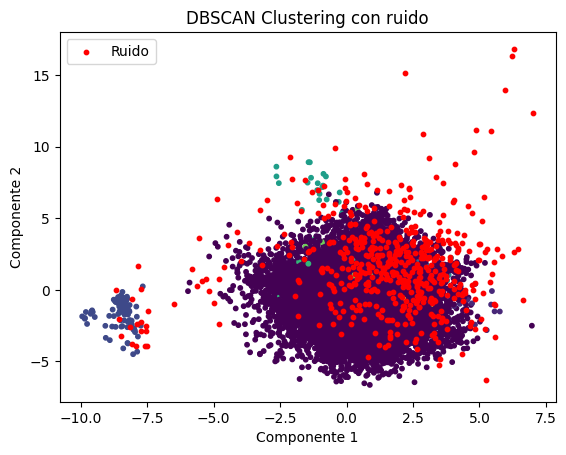

In [58]:
import matplotlib.pyplot as plt

ruido_mask = clusters == -1
grupo_mask = clusters != -1

plt.figure()

# clusters (colores)
plt.scatter(sample_pca[grupo_mask, 0], sample_pca[grupo_mask, 1], 
            c=clusters[grupo_mask], s=10)

# ruido en rojo
plt.scatter(sample_pca[ruido_mask, 0], sample_pca[ruido_mask, 1], 
            c='red', s=10, label='Ruido')

plt.title("DBSCAN Clustering con ruido")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.legend()

plt.show()